In [124]:
import numpy as np
import importlib
import Sim_Parameters
#from config import *
from simulation import run
from visualize import plot_initial, plot_trajectory, plot_force
import numpy as np
from integrator import step
from driving import update_traps
from forces import trap_force
from hydrodynamics import mobility_matrix
from simulation import run
import matplotlib.pyplot as plt

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


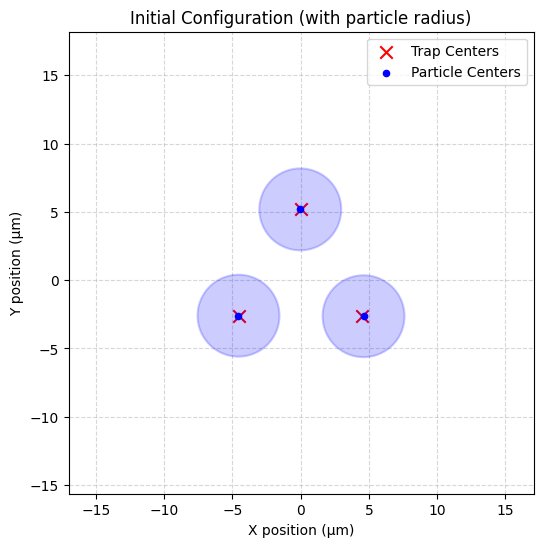

[[ 4.60677562e-06 -2.63760171e-06]
 [-2.66155541e-08  5.18527079e-06]
 [-4.55153083e-06 -2.59842936e-06]]


In [125]:
importlib.reload(Sim_Parameters)
from Sim_Parameters import *
# Initial visualization
plot_initial(pos0, trap0, a)
print(pos0)

In [126]:
H = mobility_matrix(pos0, eta)
print("Mobility Matrix H:")
print(H)
D = kBT * (H + H.T) / 2  # Ensure symmetry
A = np.linalg.cholesky(D )
print("Cholesky factor A:")
with np.printoptions(precision=2, suppress=False, formatter={'float': '{:.2e}'.format}):
    print(A)

Mobility Matrix H:
[[20000000.                0.          6234724.87387315 -2170151.84143047
   9826964.62055618   -21015.99217216]
 [       0.         20000000.         -2170151.84143047  8613387.00697533
    -21015.99217216  4913617.14620684]
 [ 6234724.87387315 -2170151.84143047 20000000.                0.
   6260580.44175656  2171662.65349755]
 [-2170151.84143047  8613387.00697533        0.         20000000.
   2171662.65349755  8733788.81425506]
 [ 9826964.62055618   -21015.99217216  6260580.44175656  2171662.65349755
  20000000.                0.        ]
 [  -21015.99217216  4913617.14620684  2171662.65349755  8733788.81425506
         0.         20000000.        ]]
Cholesky factor A:
[[2.87e-07 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [0.00e+00 2.87e-07 0.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [8.94e-08 -3.11e-08 2.71e-07 0.00e+00 0.00e+00 0.00e+00]
 [-3.11e-08 1.24e-07 2.45e-08 2.56e-07 0.00e+00 0.00e+00]
 [1.41e-07 -3.01e-10 4.85e-08 4.76e-08 2.40e-07 0.00e+00]
 [-3.01e-10

In [127]:
print(steps)

100000


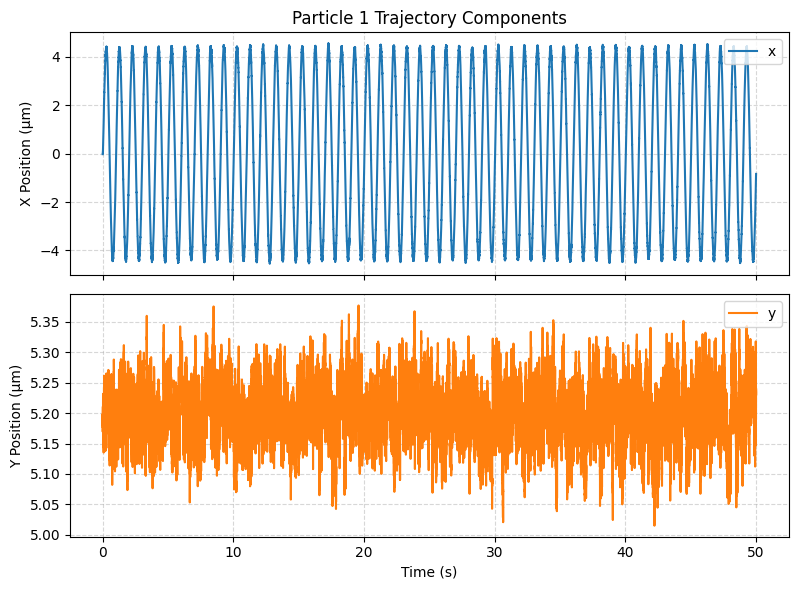

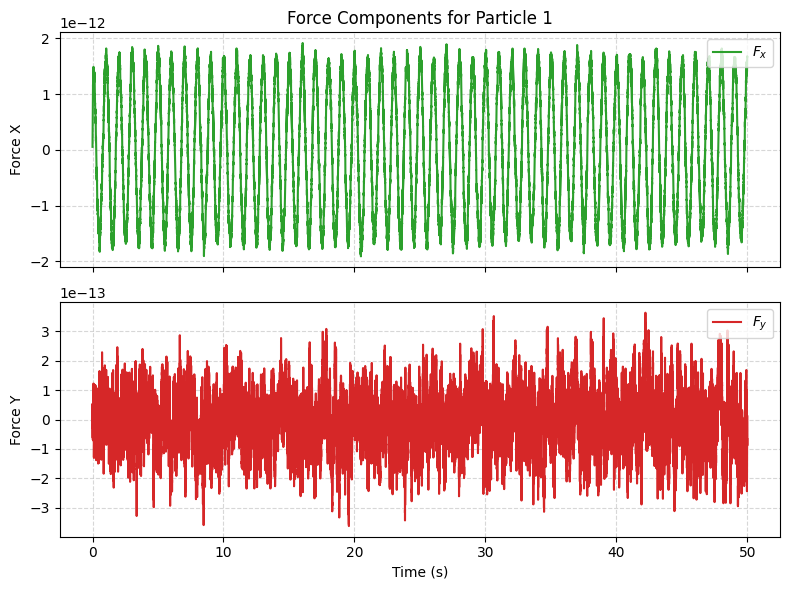

In [128]:
# Run simulation
traj, forces, traps = run(
    pos0,
    trap0,
    kappa,
    drive,
    eta,
    dt,
    steps
)

# After shear
plot_trajectory(traj, dt,particle=1)
plot_force(forces, dt,particle=1)

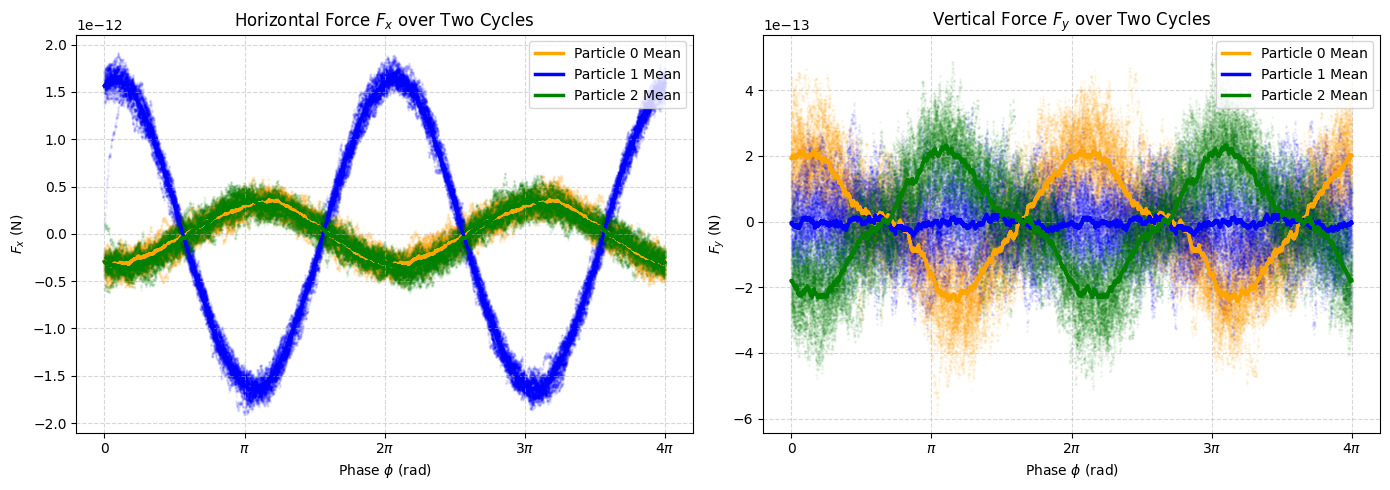

NameError: name 'cycle_labels_done' is not defined

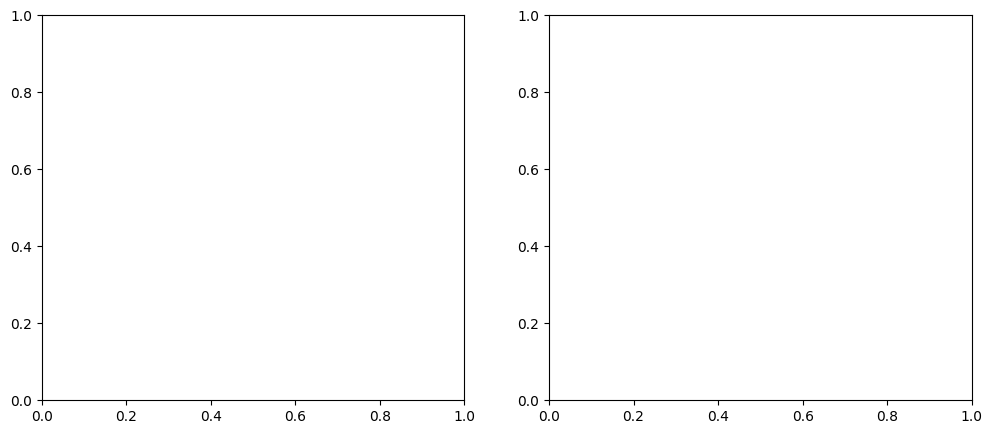

In [139]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. System Parameters & Time Reconstruction ---
omega = 1 * 2 * np.pi
dt = 5e-4  # Your actual dt
t = np.arange(len(forces)) * dt

# CRITICAL CHANGE: Wrap phase to 4*pi to show exactly two cycles side-by-side
phi_2cycles = (omega * t) % (4 * np.pi)

# --- 2. Compute the Mean Profile Over All Cycles ---
steps_per_period = int(round((2 * np.pi / omega) / dt))  # Steps in 1 cycle (8000)
num_periods = len(forces) // steps_per_period
forces_trimmed = forces[:num_periods * steps_per_period]

# Calculate the clean 1-cycle mean
periodic_forces = forces_trimmed.reshape(num_periods, steps_per_period, 3, 2)
mean_profile_1cycle = np.mean(periodic_forces, axis=0)  # Shape: (steps_per_period, 3, 2)

# --- 3. Replicate the Mean Profile for a Two-Cycle Display Window ---
# Create a smooth, linear phase array for 1 cycle, then chain it for the second cycle
phi_mean_1cycle = np.linspace(0, 2 * np.pi, steps_per_period, endpoint=False)
phi_mean_2cycles = np.concatenate([phi_mean_1cycle, phi_mean_1cycle + 2 * np.pi])

# Duplicate the mean force data back-to-back to match the 2-cycle phase axis
mean_profile_2cycles = np.concatenate([mean_profile_1cycle, mean_profile_1cycle], axis=0)

# --- 4. Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
colors = ['orange', 'blue', 'green']  # 0: Right, 1: Top, 2: Left

for p in [0, 1, 2]:
    # --- Subplot 1: Fx ---
    # 1. Raw scatter points across all cycles mapped into a 2-cycle viewport
    axes[0].scatter(phi_2cycles, forces[:, p, 0], color=colors[p], s=1, alpha=0.05, zorder=1)
    # 2. Solid period-averaged trend line mapped over the 2 cycles
    axes[0].plot(phi_mean_2cycles, mean_profile_2cycles[:, p, 0], color=colors[p], lw=2.5, label=f'Particle {p} Mean', zorder=2)

    # --- Subplot 2: Fy ---
    # 1. Raw scatter points
    axes[1].scatter(phi_2cycles, forces[:, p, 1], color=colors[p], s=1, alpha=0.05, zorder=1)
    # 2. Solid trend line
    axes[1].plot(phi_mean_2cycles, mean_profile_2cycles[:, p, 1], color=colors[p], lw=2.5, label=f'Particle {p} Mean', zorder=2)

# Styling adjustments
axes[0].set_title("Horizontal Force $F_x$ over Two Cycles")
axes[0].set_xlabel("Phase $\phi$ (rad)")
axes[0].set_ylabel("$F_x$ (N)")
axes[0].set_xticks([0, np.pi, 2*np.pi, 3*np.pi, 4*np.pi])
axes[0].set_xticklabels(['0', '$\pi$', '$2\pi$', '$3\pi$', '$4\pi$'])
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc="upper right")

axes[1].set_title("Vertical Force $F_y$ over Two Cycles")
axes[1].set_xlabel("Phase $\phi$ (rad)")
axes[1].set_ylabel("$F_y$ (N)")
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

# 1. Define your driving frequency
omega = 0.25 * 2 * np.pi

# 2. Reconstruct your time array if you don't have it
# Assuming 'dt' is your simulation time step size

t = np.arange(len(forces)) * dt

# 3. Calculate phi (wrapped between 0 and 2*pi for clean phase plots)
phi = (omega * t) % (2 * np.pi)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Assuming you have 'traj', 'forces', and 'phi' (driving phase from 0 to 2*pi)
# phi shape: (num_timesteps,)
# forces shape: (num_timesteps, 3, 2)

# 1. Plot Phase Space: (Phi, Fx) and (Phi, Fy)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

colors = ['orange', 'blue', 'green'] # 0: Right, 1: Top, 2: Left

for p in [0, 1, 2]:
    axes[0].scatter(phi, forces[:, p, 0], color=colors[p], s=1, alpha=0.1, label=f'Particle {p}' if cycle_labels_done else "")
    axes[1].scatter(phi, forces[:, p, 1], color=colors[p], s=1, alpha=0.1, label=f'Particle {p}' if cycle_labels_done else "")


    #axes[0].scatter(phi, traj[:, p, 0]-traps[:,p,0], label=f'Particle {p}', color=colors[p], lw=2)
    #axes[1].scatter(phi, traj[:, p, 1]-traps[:,p,1], label=f'Particle {p}', color=colors[p], lw=2)

axes[0].set_title("Horizontal Force $F_x$ vs Phase $\phi$")
axes[0].set_xlabel("Phase $\phi$ (rad)")
axes[0].set_ylabel("$F_x$ (N)")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Vertical Force $F_y$ vs Phase $\phi$")
axes[1].set_xlabel("Phase $\phi$ (rad)")
axes[1].set_ylabel("$F_y$ (N)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 2. Compute Correlation Matrix for all Force Components
# Flatten the force components into a structured DataFrame
force_data = {
    'P0_Fx': forces[:, 0, 0], 'P0_Fy': forces[:, 0, 1],
    'P1_Fx': forces[:, 1, 0], 'P1_Fy': forces[:, 1, 1],
    'P2_Fx': forces[:, 2, 0], 'P2_Fy': forces[:, 2, 1]
}
df_forces = pd.DataFrame(force_data)
correlation_matrix = df_forces.corr()

print("Force Components Correlation Matrix:")
print(correlation_matrix.round(3))




In [130]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def animate_trajectory(traj, forces, traps, a, save_gif=False, filename="particle_motion.gif"):
    """
    Animates dynamic particles, dynamic traps, and force vectors.
    traj: shape (frames, 3, 2) -> [frame, particle, (x, y)]
    forces: shape (frames, 3, 2) -> [frame, particle, (fx, fy)]
    traps: shape (frames, 3, 2) -> [frame, trap, (x, y)]
    a: particle radius (meters)
    """
    # Scale from meters to micrometers
    traj_um = traj * 1e6
    forces_scaled = forces * 1e12  # Scale forces to make vectors visually trackable
    traps_um = traps * 1e6
    a_um = a * 1e6

    fig, ax = plt.subplots(figsize=(7, 7))
    
    # Initialize dynamic elements
    colors = ['orange', 'blue', 'green'] # 0: Right, 1: Top, 2: Left
    zeros_3 = np.zeros(3)
    
    # FIX: Initialize traps as a dynamic scatter plot with 3 points
    scat_traps = ax.scatter(zeros_3, zeros_3, c="red", marker="x", s=80, label="Trap Centers", zorder=4)
    
    # Initialize particle center scatter plot
    scat = ax.scatter(zeros_3, zeros_3, c=colors, s=30, zorder=3)
    
    circles = [plt.Circle((0, 0), radius=a_um, color=colors[i], alpha=0.15, ec=colors[i], lw=1.5, zorder=2) for i in range(3)]
    for circle in circles:
        ax.add_patch(circle)
        
    # Initialize force vector fields
    quiver_net = ax.quiver(zeros_3, zeros_3, zeros_3, zeros_3, color='black', scale=1, angles='xy', scale_units='xy', label='Net Force', zorder=5)
    quiver_x = ax.quiver(zeros_3, zeros_3, zeros_3, zeros_3, color='red', alpha=0.5, angles='xy', scale_units='xy', width=0.004, zorder=4)
    quiver_y = ax.quiver(zeros_3, zeros_3, zeros_3, zeros_3, color='blue', alpha=0.5, angles='xy', scale_units='xy', width=0.004, zorder=4)

    # Set rigid viewport bounds based on maximum trajectory excursions
    max_val = max(np.max(np.abs(traj_um)), np.max(np.abs(traps_um))) + 2 * a_um
    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    ax.set_aspect('equal')
    ax.set_xlabel("X ($\mu$m)")
    ax.set_ylabel("Y ($\mu$m)")
    ax.set_title("Particle Dynamics & Force Vector Fields")
    ax.legend(loc="upper right")
    ax.grid(True, linestyle='--', alpha=0.5)

    def update(frame):
        pos = traj_um[frame]         # Shape (3, 2)
        f_net = forces_scaled[frame] # Shape (3, 2)
        current_traps = traps_um[frame] # Shape (3, 2)
        
        # Update dynamic trap centers
        scat_traps.set_offsets(current_traps)
        
        # Update particle center markers
        scat.set_offsets(pos)
        
        # Update particle outer boundary patches
        for i, circle in enumerate(circles):
            circle.set_center((pos[i, 0], pos[i, 1]))
            
        # Update force vector origins
        quiver_net.set_offsets(pos)
        quiver_x.set_offsets(pos)
        quiver_y.set_offsets(pos)
        
        # Update force vector lengths/directions
        quiver_net.set_UVC(f_net[:, 0], f_net[:, 1])
        quiver_x.set_UVC(f_net[:, 0], np.zeros(3))
        quiver_y.set_UVC(np.zeros(3), f_net[:, 1])
        
        return [scat_traps, scat, quiver_net, quiver_x, quiver_y] + circles

    # No init_func needed; blit=False guarantees error-free GIF saving
    ani = animation.FuncAnimation(fig, update, frames=len(traj), blit=False, interval=30)
    
    if save_gif:
        ani.save(filename, writer='pillow', fps=10)
        print(f"Animation successfully saved as {filename}")
        
    plt.show()


Animation successfully saved as coarse_particle_motion.gif


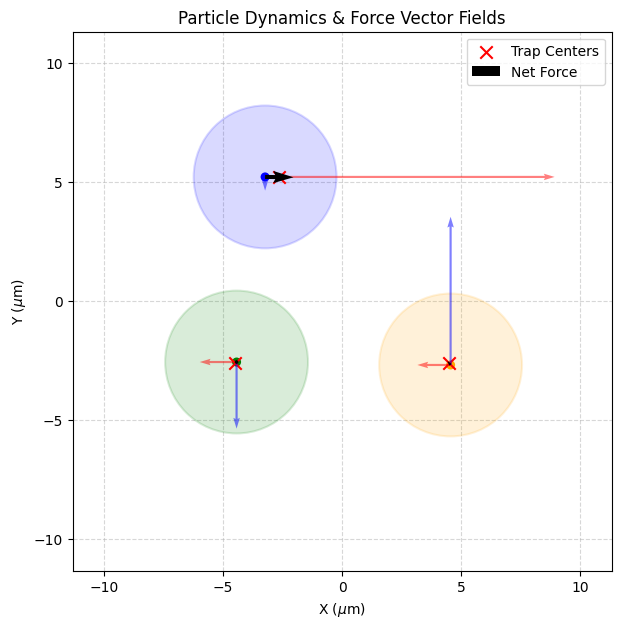

In [131]:
# 1. Define your original simulation properties
dt_original = 5e-4  # 0.0005 seconds
total_duration = 50  # seconds
total_steps = 100000

# 2. Choose your downsampling step size
# Taking every 66th frame maps 100,000 steps to ~1,515 frames.
# Played back at 30 fps, 1515 / 30 = ~50 seconds of video (True Real-Time speed!)
coarse_grain_step = total_steps // (total_duration * 10)  # 30 fps for GIF

# 3. Create the coarse-grained data slices
traj_coarse = traj[::coarse_grain_step]
forces_coarse = forces[::coarse_grain_step]
traps_coarse = traps[::coarse_grain_step]

# 4. Pass the downsampled datasets into your function
animate_trajectory(
    traj=traj_coarse, 
    forces=forces_coarse, 
    traps=traps_coarse, 
    a=a, 
    save_gif=True, 
    filename="coarse_particle_motion.gif"
)


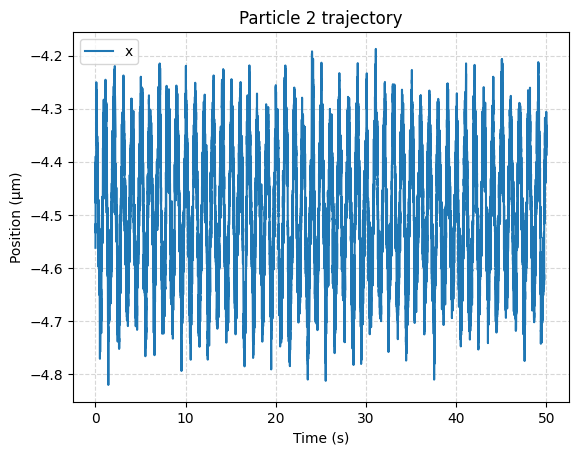

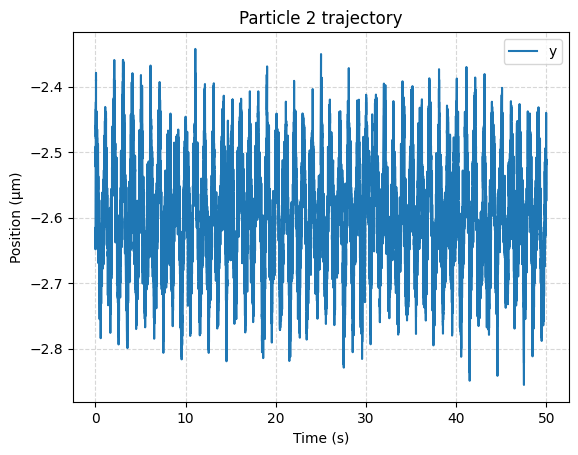

In [132]:
num_steps = len(traj)

    # Create an array of timestamps: [0, dt, 2*dt, ..., (num_steps-1)*dt]
time_axis = np.arange(num_steps) * dt
particle = 2
plt.figure()

    # Plot x  coordinates against the physical time axis
plt.plot(time_axis, traj[:, particle, 0]*1e6, label="x")
    

plt.xlabel("Time (s)")  # Added axis label
plt.ylabel("Position (μm)")
plt.legend()
plt.title(f"Particle {particle} trajectory")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

plt.figure()

# Plot y coordinates against the physical time axis

plt.plot(time_axis, traj[:, particle, 1]*1e6, label="y")

plt.xlabel("Time (s)")  # Added axis label
plt.ylabel("Position (μm)")
plt.legend()
plt.title(f"Particle {particle} trajectory")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

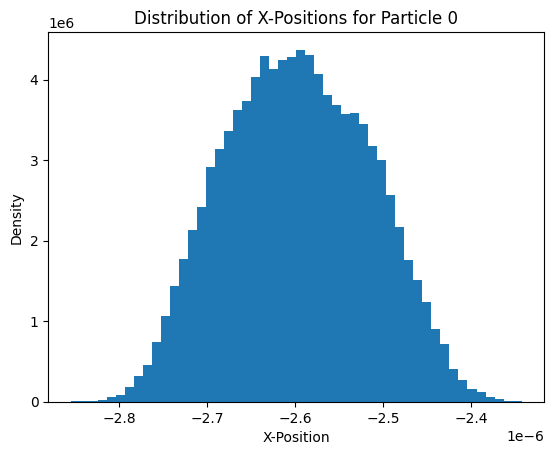

In [133]:
plt.figure()
# Plot histogram of x-positions of particle 0
plt.hist(traj[:, 2, 1], bins=50, density=True)
plt.xlabel("X-Position")
plt.ylabel("Density")
plt.title("Distribution of X-Positions for Particle 0")
plt.show()

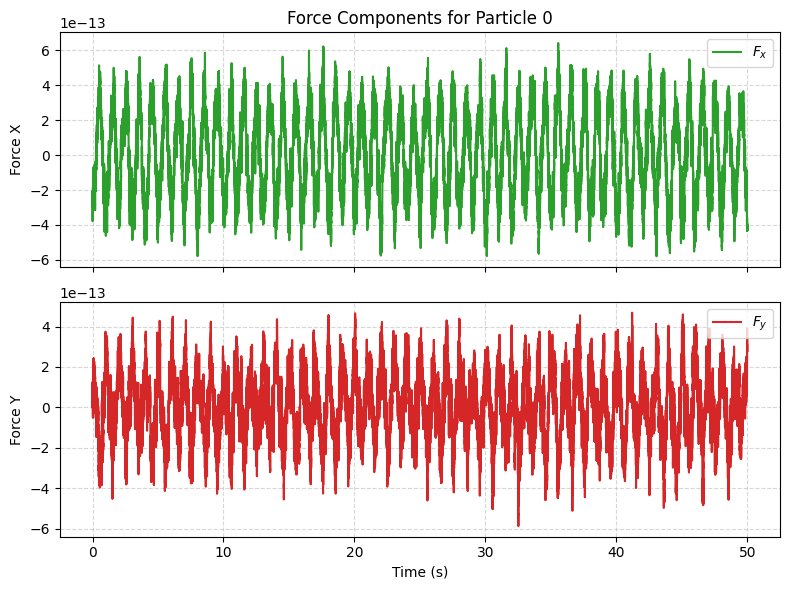

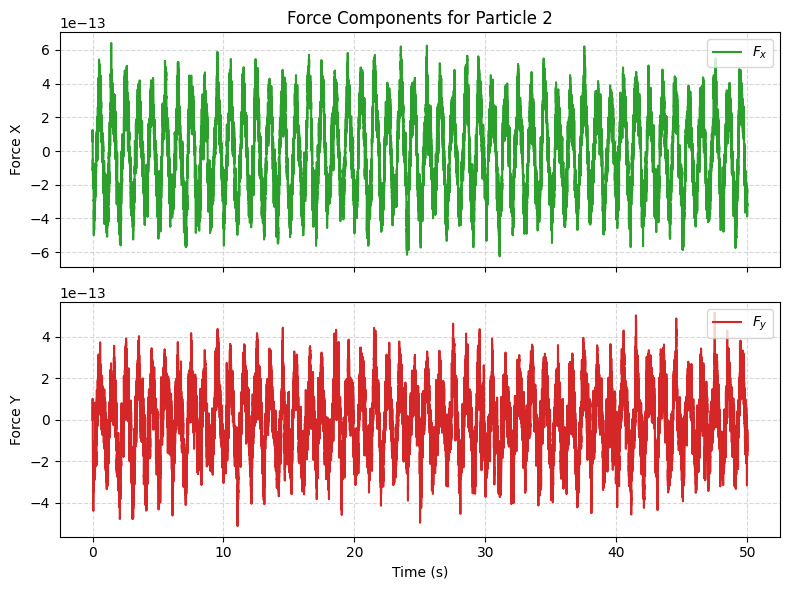

In [134]:
plot_force(forces, dt,particle=0)
plot_force(forces, dt,particle=2)

In [135]:
x = traj[:, 2,0]
print(6 * np.pi * eta * a)
kBT = 1.38e-23 * (273 + 25)
k_eff = kBT / np.var(x)
print(f"Effective stiffness from trajectory: {k_eff:.2e} N/m")

5e-08
Effective stiffness from trajectory: 2.59e-07 N/m
